# Presentation Visualizations

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT))
DATA_PATH = ROOT / "data" / "processed"
OUT_PATH = ROOT / "outputs" / "stage1"

FEATURES_CSV = DATA_PATH / "customer_churn_features.csv"
HIGH_RISK_CSV = OUT_PATH / "high_risk_customers.csv"
if not FEATURES_CSV.exists():
    raise FileNotFoundError(f"Run pipeline first. Expected {FEATURES_CSV}")

df = pd.read_csv(FEATURES_CSV)
drop_cols = ["churn_risk_score", "security_no", "value_segment", "engagement_segment", "price_sensitivity", "profile_tags"]
drop_cols = [c for c in drop_cols if c in df.columns]
X = df.drop(columns=drop_cols)
y = df["churn_risk_score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data loaded.")

Data loaded.


## EDA Figures

Exploratory data analysis of the customer churn dataset: distribution of churn risk, key drivers (membership, feedback, tenure), correlation heatmap, and segment-level patterns.

In [ ]:
# Display EDA figures
from IPython.display import Image, display

FIG_DIR = Path("figures")
eda_figures = [
    "01_churn_distribution.png",
    "02_churn_by_membership.png",
    "03_numeric_by_churn.png",
    "04_correlation_heatmap.png",
    "05_churn_by_segments.png",
    "06_complaint_support_churn.png",
    "07_tenure_distribution.png",
    "08_churn_by_price_sensitivity.png",
]

for fname in eda_figures:
    path = FIG_DIR / fname
    if path.exists():
        display(Image(filename=str(path), width=700))

## 1. Feature importance (Random Forest)

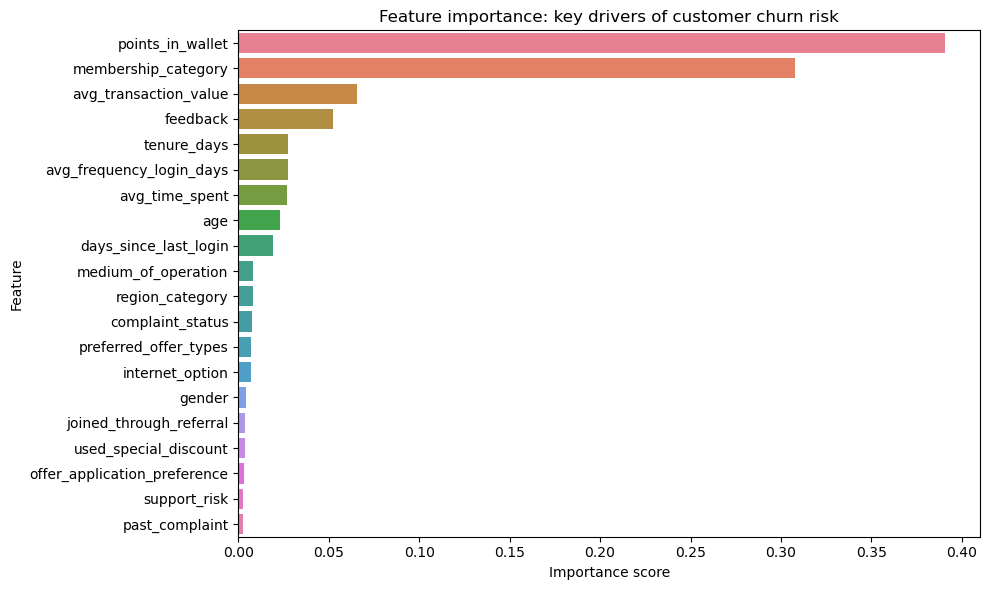

In [2]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
imp = pd.DataFrame({"Feature": X_train.columns, "Importance": rf.feature_importances_}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=imp, hue="Feature", legend=False)
plt.title("Feature importance: key drivers of customer churn risk")
plt.xlabel("Importance score")
plt.tight_layout()
plt.show()

## 2. Confusion matrix (HistGradientBoosting, test set)

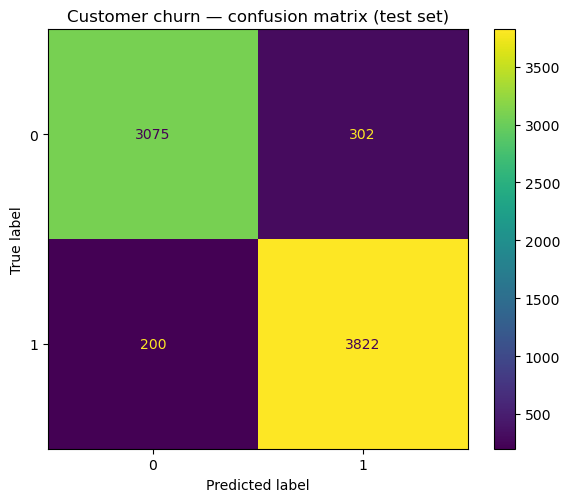

In [3]:
model = HistGradientBoostingClassifier(max_iter=150, max_depth=6, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
plt.title("Customer churn — confusion matrix (test set)")
plt.tight_layout()
plt.show()

## 3. Segment distribution (risk × value)

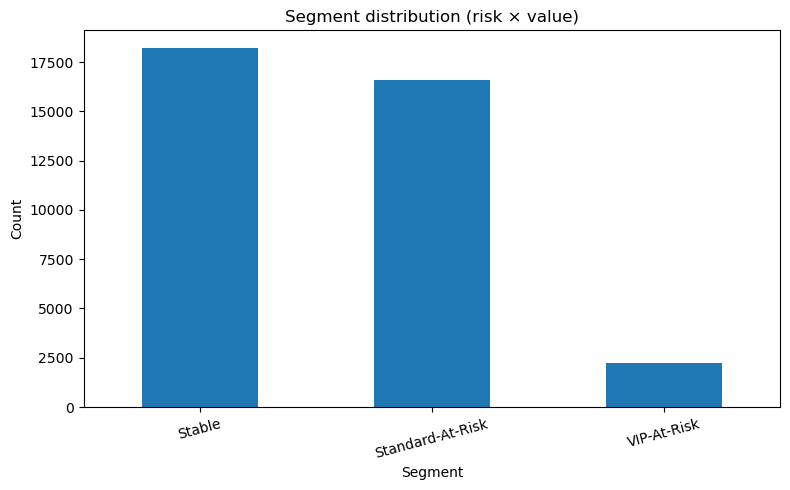

In [4]:
prob = model.predict_proba(df[X_train.columns])[:, 1]
risk_df = df.copy()
risk_df["churn_probability"] = prob
point_median = risk_df["points_in_wallet"].median()
risk_df["segment"] = np.where(
    (risk_df["churn_probability"] > 0.7) & (risk_df["points_in_wallet"] > point_median),
    "VIP-At-Risk",
    np.where(risk_df["churn_probability"] > 0.7, "Standard-At-Risk", "Stable"),
)
counts = risk_df["segment"].value_counts()

plt.figure(figsize=(8, 5))
counts.plot(kind="bar")
plt.title("Segment distribution (risk × value)")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. Stage 2 campaign mix

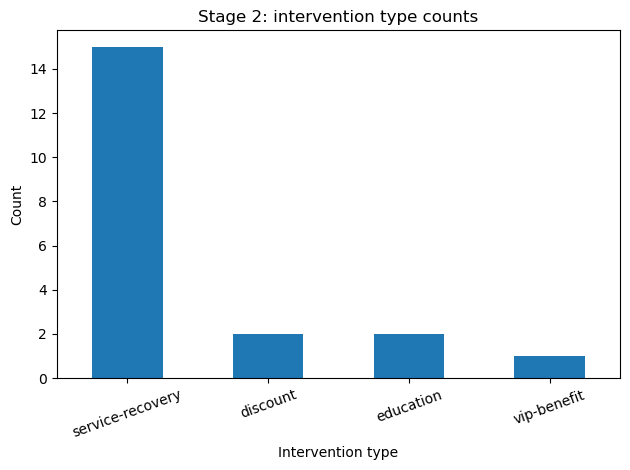

In [5]:
import json
stage2_dir = ROOT / "outputs" / "stage2"
runs = sorted(stage2_dir.glob("*/customer_campaign_plans.json")) if stage2_dir.exists() else []
if runs:
    with open(runs[-1]) as f:
        data = json.load(f)
    strategies = [p.get("strategy", {}) for p in data["customers"]]
    strat_df = pd.DataFrame(strategies)
    if "intervention_type" in strat_df.columns:
        strat_df["intervention_type"].value_counts().plot(kind="bar")
        plt.title("Stage 2: intervention type counts")
        plt.xlabel("Intervention type")
        plt.ylabel("Count")
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()
else:
    print("No Stage 2 runs found. Run pipeline with --stage2 to generate campaign plans.")

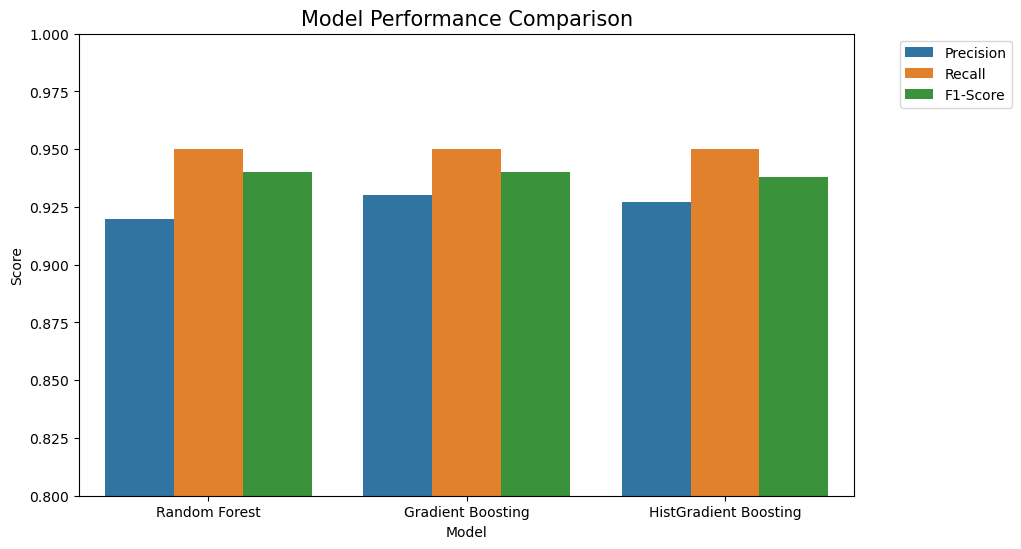

/var/folders/h0/1t_8wxys0c38mc2r9613xgjm0000gn/T/ipykernel_78389/3685582337.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_feedback, y='Feedback Type', x='Average Risk Score', palette='Reds_r')


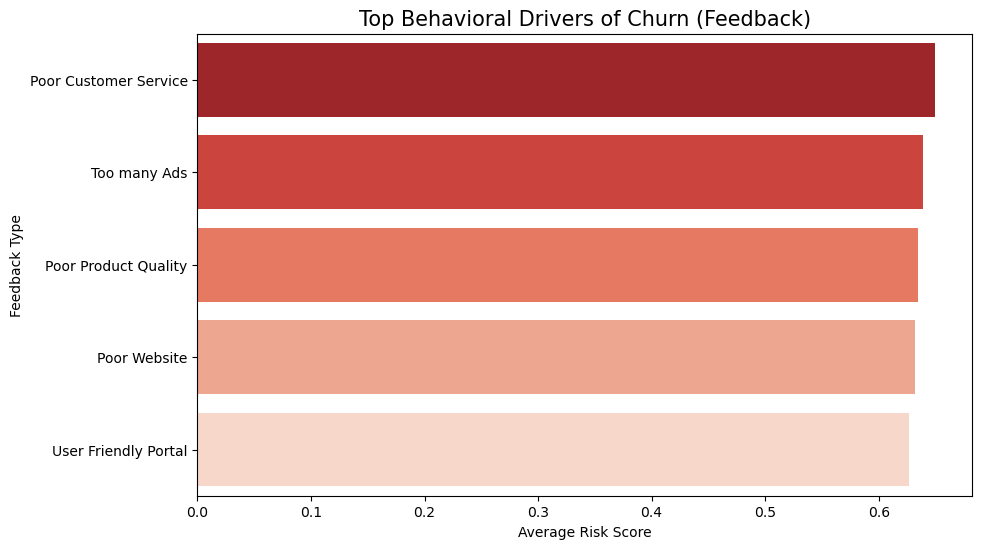

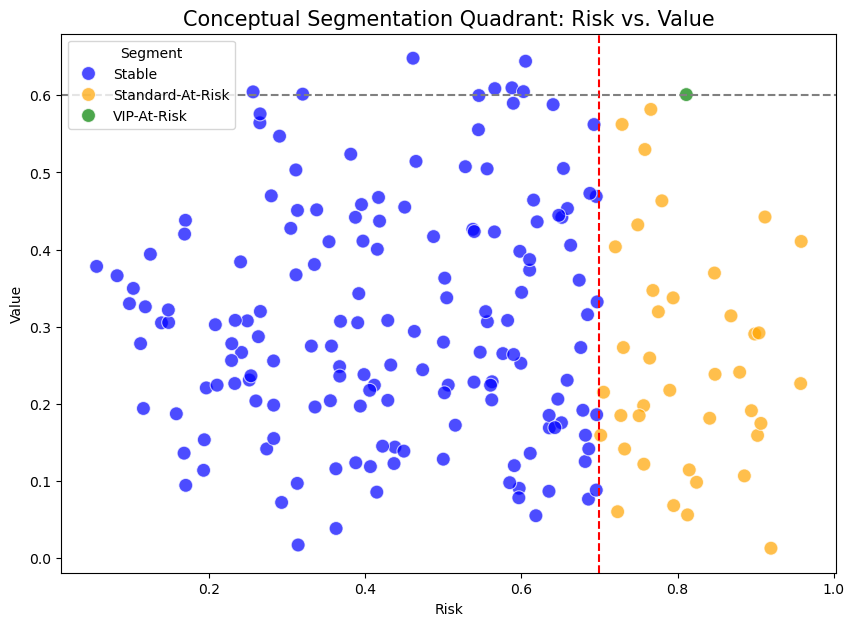

In [1]:
# Additional Visuals for Presentation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Model Performance Comparison
models = ['Random Forest', 'Gradient Boosting', 'HistGradient Boosting']
precision = [0.92, 0.93, 0.927]
recall = [0.95, 0.95, 0.950]
f1 = [0.94, 0.94, 0.938]

df_perf = pd.DataFrame({
    'Model': models * 3,
    'Metric': ['Precision']*3 + ['Recall']*3 + ['F1-Score']*3,
    'Score': precision + recall + f1
})

plt.figure(figsize=(10, 6))
sns.barplot(data=df_perf, x='Model', y='Score', hue='Metric')
plt.title('Model Performance Comparison', fontsize=15)
plt.ylim(0.8, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 2. Churn Drivers - Feedback (Using specific values from notebook 02)
feedback_data = {
    'Feedback Type': ['Poor Customer Service', 'Too many Ads', 'Poor Product Quality', 'Poor Website', 'User Friendly Portal'],
    'Average Risk Score': [0.6499, 0.6385, 0.6349, 0.6317, 0.6270]
}
df_feedback = pd.DataFrame(feedback_data).sort_values('Average Risk Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_feedback, y='Feedback Type', x='Average Risk Score', palette='Reds_r')
plt.title('Top Behavioral Drivers of Churn (Feedback)', fontsize=15)
plt.show()

# 3. Risk vs Value Quadrant
np.random.seed(42)
n = 200
risk = np.random.beta(2, 2, n)
value = np.random.beta(2, 5, n)

def assign_seg(r, v):
    if r > 0.7:
        return 'VIP-At-Risk' if v > 0.6 else 'Standard-At-Risk'
    return 'Stable'

df_quad = pd.DataFrame({'Risk': risk, 'Value': value})
df_quad['Segment'] = df_quad.apply(lambda row: assign_seg(row['Risk'], row['Value']), axis=1)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_quad, x='Risk', y='Value', hue='Segment', 
                palette={'Stable': 'blue', 'Standard-At-Risk': 'orange', 'VIP-At-Risk': 'green'}, s=100, alpha=0.7)
plt.axvline(0.7, color='red', linestyle='--')
plt.axhline(0.6, color='gray', linestyle='--')
plt.title('Conceptual Segmentation Quadrant: Risk vs. Value', fontsize=15)
plt.show()